# РТ ОМО 2 Супонова София

## Задание 1

Создайте класс по работе с тригонометрическими функциями. В классе
должны быть реализованы функции вычисления:
− косинуса;
− синуса;
− тангенса;
− арксинуса;
− арккосинуса;
− арктангенса;
− перевода из градусов в радианы.

In [1]:
import math


class TTrigonometry:
    @staticmethod
    def to_radians(degrees):
        return math.radians(degrees)

    @staticmethod
    def sin(angle):
        angle = math.radians(angle)
        return math.sin(angle)

    @staticmethod
    def cos(angle):
        angle = math.radians(angle)
        return math.cos(angle)

    @staticmethod
    def tan(angle):
        angle = math.radians(angle)
        return math.tan(angle)

    @staticmethod
    def arcsin(value):
        return math.asin(value)

    @staticmethod
    def arccos(value):
        return math.acos(value)

    @staticmethod
    def arctan(value):
        return math.atan(value)


trig = TTrigonometry()
print(f'синус 30: {trig.sin(30)}')
print(f'косинус 60: {trig.cos(60)}')
print(f'тангенс 45: {trig.tan(45)}')
print(f'арксинус 0.5: {trig.arcsin(0.5)}')
print(f'45 в радианах: {trig.to_radians(45)}')

синус 30: 0.49999999999999994
косинус 60: 0.5000000000000001
тангенс 45: 0.9999999999999999
арксинус 0.5: 0.5235987755982989
45 в радианах: 0.7853981633974483


## Задание 2

Представьте дерево показанное на рисунке с использованием списка из
списков. Выведите на печать корень дерева, а также его левое и правое
поддеревья.

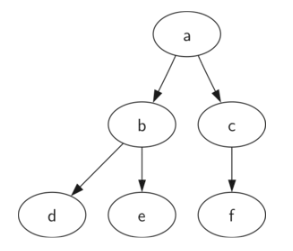

In [2]:
answ = ['a',
        ['b', # 1ый потомок
         ['d', [], []],
         ['e', [], []]
         ],
        ['c', # второй потомок
         ['f', [], []]],
         []
        ]

## Задание 3

Дан класс, описывающий бинарное дерево.
class Tree:
    def __init__(self, data):
        self.left = None
        self.right = None
        self.data = data
    def PrintTree(self):
        print(self.data)
Реализуйте в классе функцию для вставки нового элемента в дерево по
следующим правилам:
• Левое поддерево узла содержит только узлы со значениями меньше,
чем значение в узле.
• Правое поддерево узла содержит только узлы со значениями меньше,
чем значение в узле.
• Каждое из левого и правого поддеревьев также должно быть
бинарным деревом поиска.
• Не должно быть повторяющихся узлов.
Метод вставки сравнивает значение узла с родительским узлом и решает
куда доваить элемент (в левое или правое поддерево). Перепишите, метод
PrintTree для печати полной версии дерева

In [3]:
class Tree:
    def __init__(self, data):
        self.left = None
        self.right = None
        self.data = data

    def insert(self, data):
        if data == self.data:
            return

        if data < self.data:
            if self.left is None:
                self.left = Tree(data)
            else:
                self.left.insert(data)
        else:
            if self.right is None:
                self.right = Tree(data)
            else:
                self.right.insert(data)

    def PrintTree(self, level=0, prefix=''):
        print(' ' * (level * 4) + prefix + str(self.data))
        if self.left:
            self.left.PrintTree(level + 1, 'L--- ')
        if self.right:
            self.right.PrintTree(level + 1, 'R--- ')


root = Tree(50)
val = [30, 70, 20, 40, 60, 80, 10, 25, 35, 45]

for i in val:
    root.insert(i)
root.PrintTree()

50
    L--- 30
        L--- 20
            L--- 10
            R--- 25
        R--- 40
            L--- 35
            R--- 45
    R--- 70
        L--- 60
        R--- 80


## Задание 4

Постройте классификатор на основе дерева принятия решений
следующего датасета:

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

X = np.array([[-1, 1], [-2, -1], [-3, -2], [1, 1], [2, 1], [3, 2]])
target = [0, 0, 0, 1, 1, 1]
df = pd.DataFrame(X, columns=['1 признак', '2 признак'])
df['Целевые значения'] = target
df

,1 признак,2 признак,Целевые значения
0,-1,1,0
1,-2,-1,0
2,-3,-2,0
3,1,1,1
4,2,1,1
5,3,2,1


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df.iloc[:, :-1],
    df.iloc[:, -1],
    test_size=0.2
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(4, 2) (2, 2) (4,) (2,)


In [6]:
X_train.head()

,1 признак,2 признак
5,3,2
3,1,1
1,-2,-1
2,-3,-2


In [7]:
y_train.head()

5    1
3    1
1    0
2    0
Name: Целевые значения, dtype: int64

In [8]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier()
classifier.fit(X_train, y_train)

DecisionTreeClassifier()

[Text(0.5, 0.75, 'x[0] <= -0.5\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.625, 0.5, '  False')]

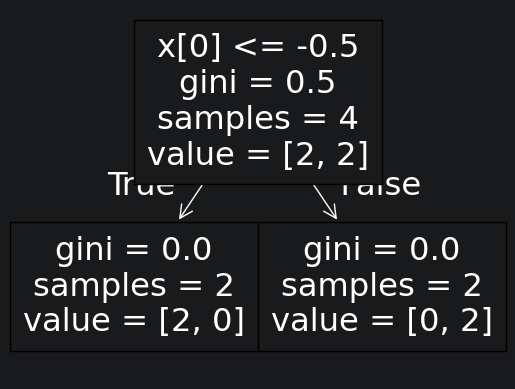

In [9]:
from sklearn import tree
tree.plot_tree(classifier)

In [10]:
y_pred = classifier.predict(X_test)
y_pred

array([1, 0])

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1 0]
 [0 1]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



## Задание 5

Задание. Постройте модель регрессии DecisionTreeRegressor. Для примера
можно взять потребления газа (в миллионах галлонов) в 48 штатах США
или набор данных о качестве красного вина:
https://raw.githubusercontent.com/likarajo/petrol_consumption/master/data/pet
rol_consumption.csv
https://raw.githubusercontent.com/aniruddhachoudhury/Red-Wine-
Quality/master/winequality-red.csv
Постройте прогноз. Оцените точность модели.

In [12]:
url = r'https://raw.githubusercontent.com/aniruddhachoudhury/Red-Wine-Quality/master/winequality-red.csv'
df = pd.read_csv(url)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [13]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [14]:
print(df.shape)

(1599, 12)


In [15]:
import matplotlib.pyplot as plt

X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor()
regressor.fit(X_train, y_train)

DecisionTreeRegressor()

[Text(0.45869898415610916, 0.9807692307692307, 'x[10] <= 10.525\nsquared_error = 0.651\nsamples = 1279\nvalue = 5.624'),
 Text(0.2168497894841028, 0.9423076923076923, 'x[9] <= 0.575\nsquared_error = 0.437\nsamples = 786\nvalue = 5.36'),
 Text(0.33777438682010597, 0.9615384615384615, 'True  '),
 Text(0.10096235838713608, 0.9038461538461539, 'x[7] <= 1.001\nsquared_error = 0.343\nsamples = 314\nvalue = 5.131'),
 Text(0.09784382994274576, 0.8653846153846154, 'x[4] <= 0.251\nsquared_error = 0.329\nsamples = 313\nvalue = 5.137'),
 Text(0.09472530149835547, 0.8269230769230769, 'x[9] <= 0.525\nsquared_error = 0.316\nsamples = 312\nvalue = 5.144'),
 Text(0.03157510049945182, 0.7884615384615384, 'x[3] <= 1.25\nsquared_error = 0.276\nsamples = 155\nvalue = 5.032'),
 Text(0.028456572055061517, 0.75, 'squared_error = 0.0\nsamples = 1\nvalue = 7.0'),
 Text(0.03469362894384213, 0.75, 'x[8] <= 3.225\nsquared_error = 0.253\nsamples = 154\nvalue = 5.019'),
 Text(0.012474113777561214, 0.7115384615384616

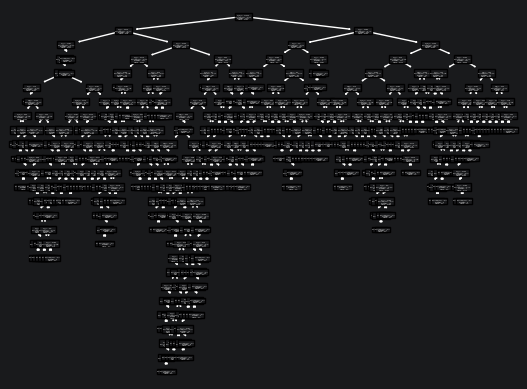

In [17]:
from sklearn import tree
tree.plot_tree(regressor)

In [18]:
y_pred = regressor.predict(X_test)
y_pred

array([6., 5., 5., 5., 6., 5., 5., 5., 7., 6., 7., 6., 6., 5., 6., 6., 5.,
       6., 6., 5., 5., 6., 5., 6., 5., 6., 6., 5., 5., 6., 5., 5., 6., 6.,
       6., 5., 6., 6., 5., 6., 3., 5., 7., 5., 5., 5., 6., 6., 5., 6., 5.,
       5., 6., 7., 5., 6., 6., 6., 5., 5., 6., 7., 6., 6., 6., 5., 7., 6.,
       5., 6., 6., 5., 6., 6., 6., 5., 6., 5., 6., 7., 5., 7., 5., 6., 7.,
       6., 5., 6., 6., 6., 7., 6., 5., 5., 5., 5., 5., 6., 5., 5., 5., 5.,
       6., 7., 6., 7., 6., 6., 4., 5., 6., 5., 7., 5., 4., 6., 5., 5., 5.,
       6., 6., 6., 6., 6., 6., 5., 6., 5., 5., 6., 6., 6., 4., 6., 6., 5.,
       5., 6., 5., 6., 7., 7., 8., 6., 5., 5., 5., 6., 5., 5., 6., 6., 5.,
       5., 6., 5., 6., 7., 5., 6., 6., 5., 5., 5., 5., 5., 6., 5., 5., 6.,
       5., 5., 7., 5., 7., 6., 7., 5., 5., 5., 5., 5., 5., 6., 4., 5., 6.,
       6., 7., 5., 5., 7., 5., 6., 6., 5., 5., 6., 5., 7., 5., 6., 6., 5.,
       6., 5., 6., 3., 7., 7., 8., 5., 5., 7., 7., 6., 6., 5., 6., 5., 6.,
       6., 6., 5., 4., 5.

In [19]:
df_final = pd.DataFrame({'Actual:': y_test, 'Predicted:': y_pred})
df_final

,Actual:,Predicted:
803,6,6.0
124,5,5.0
350,6,5.0
682,5,5.0
1326,6,6.0
...,...,...
1259,6,6.0
1295,5,5.0
1155,5,5.0
963,6,6.0


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('MSE:', mean_squared_error(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))

MSE: 0.615625
MAE: 0.465625


In [21]:
mean_absolute_error(y_test, y_pred) / np.average(y) * 100

np.float64(8.261588715046605)

Средняя абсолютная ошибка для нашего алгоритма составляет 0.440625,
что составляет менее 8 процентов от среднего значения всех значений в
столбце.

## Задание 6

Экспериментально получены N − значений величины Y при
различных значениях величины X. По таблице построить дерево. Привести
расчет оценки ветвления. Расчеты выполняются ручкой на бумаге и
сравниваются с результатами программной реализации
DecisionTreeRegressor.

[ 0.1        -2.          0.3        -2.          0.50000001 -2.
 -2.        ]


[Text(0.3333333333333333, 0.875, 'x[0] <= 0.1\nsquared_error = 1.806\nsamples = 6\nvalue = 4.167'),
 Text(0.16666666666666666, 0.625, 'squared_error = 0.0\nsamples = 1\nvalue = 3.0'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[0] <= 0.3\nsquared_error = 1.84\nsamples = 5\nvalue = 4.4'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'squared_error = 0.0\nsamples = 1\nvalue = 6.0'),
 Text(0.6666666666666666, 0.375, 'x[0] <= 0.5\nsquared_error = 1.5\nsamples = 4\nvalue = 4.0'),
 Text(0.5, 0.125, 'squared_error = 0.0\nsamples = 1\nvalue = 3.0'),
 Text(0.8333333333333334, 0.125, 'squared_error = 1.556\nsamples = 3\nvalue = 4.333')]

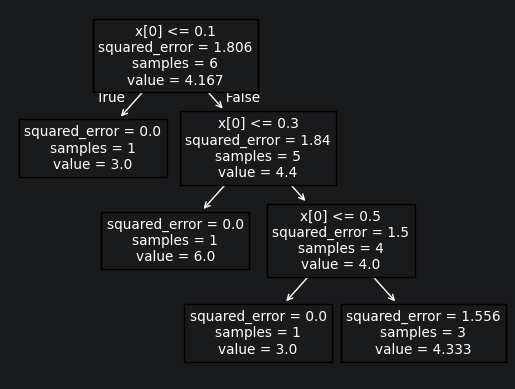

In [22]:
data_var1 = {
    'x': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    'y': [3.0, 6.0, 3.0, 6.0, 4.0, 3.0]
}
df_var1 = pd.DataFrame(data_var1)
X = df_var1[['x']]
y = df_var1['y']

regressor = DecisionTreeRegressor(random_state=42, max_depth=3)
regressor.fit(X, y)

print(regressor.tree_.threshold)
tree.plot_tree(regressor)